# Lista 3 — Padrões de sobrevivência no Titanic
**Curso:** Ciência da Computação · **Disciplina:** Inteligência Artificial  
**Professora:** Cristiane Neri Nobre · **Entrega:** 20/09 · **Valor:** 2 pontos

Este notebook adapta `../List02/titanic_imputacao_media_moda.ipynb` e
`../List02/titanic_remocao_ausentes.ipynb`: reutiliza a base, a leitura com pandas,
os gráficos de sobrevivência por sexo/classe, a divisão estratificada 80/20,
o treinamento da árvore e a extração de regras com `export_text`/`plot_tree`.
Substitui média/moda e remoção de passageiros por KNN e imputação iterativa com Random Forest,
acrescenta balanceamento, Random Forest, duas buscas e análises comparativas.

**Experimento:** 2 imputadores × 2 balanceamentos × 2 modelos × 2 otimizadores = **16 configurações**.
O item 1.b exige RandomUnderSampling portanto ele é a segunda técnica comparada com SMOTE,
apesar de os itens finais mencionarem genericamente uma “variação”. As referências a 5.b–5.f
são interpretadas como 4.b–4.f.

Execute as células em ordem. As tabelas, figuras, regras e conclusões são também salvas em
`resultados/`. A base continua em `List02`, sem duplicação nem alteração.


## 1. Ambiente e protocolo experimental
Instale as dependências com `python -m pip install -r requirements.txt` no ambiente do kernel.
O arquivo registra as versões usadas nesta execução. As sementes tornam a amostragem reproduzível
tempos dependem do computador e das versões.

Reservei 20% dos passageiros para teste antes de ajustar qualquer transformação.
Usei três folds estratificados no treino e **F1 da classe 1 (sobreviveu)** como objetivo.
Cada busca avalia 12 candidatos, com os mesmos espaços de busca e folds. O Optuna usa TPE
(otimização sequencial baseada em modelos probabilísticos), com quatro tentativas iniciais aleatórias.
É um orçamento didático, não uma busca exaustiva. A escolha final usa somente F1 de validação
o teste é consultado depois que todas as buscas terminam.


In [1]:
from pathlib import Path
from time import perf_counter
from tempfile import TemporaryDirectory
from importlib.metadata import version
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from scipy.stats import wasserstein_distance
from joblib import Memory
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.experimental import enable_iterative_imputer  # habilita API experimental
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.exceptions import ConvergenceWarning
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay
from imblearn.pipeline import Pipeline
from imblearn import FunctionSampler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import optuna

SEED = 42
N_CANDIDATOS = 12
N_FOLDS = 3
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 160)
plt.rcParams.update({'figure.figsize': (9, 4), 'axes.grid': False})

# Funciona tanto com o kernel em List03 quanto na raiz do repositório.
BASE = Path.cwd() if (Path.cwd().parent / 'List02/titanic completo.csv').exists() else Path.cwd() / 'Lists/List03'
DADOS = BASE.parent / 'List02/titanic completo.csv'
assert DADOS.exists(), f'Base não encontrada: {DADOS}. Abra o notebook em List03 ou na raiz do projeto.'
SAIDA = BASE / 'resultados'
SAIDA.mkdir(exist_ok=True)
versoes = {p: version(p) for p in ['numpy', 'pandas', 'scipy', 'scikit-learn', 'imbalanced-learn', 'optuna', 'matplotlib', 'joblib']}
display(pd.Series(versoes, name='Versão'))
(SAIDA / 'ambiente.json').write_text(json.dumps(versoes, indent=2), encoding='utf-8')

def salvar_tabela(tabela, nome):
    tabela.to_csv(SAIDA / f'{nome}.csv', index=False)
    display(tabela)

def salvar_figura(nome):
    plt.tight_layout()
    plt.savefig(SAIDA / f'{nome}.png', dpi=140, bbox_inches='tight')
    plt.show()
    plt.close()


numpy                2.5.2
pandas               3.0.5
scipy               1.18.1
scikit-learn         1.9.0
imbalanced-learn    0.14.2
optuna               5.0.0
matplotlib          3.11.1
joblib               1.5.3
Name: Versão, dtype: str

In [2]:
df = pd.read_csv(DADOS)
assert df.shape[0] == 1309 and df['survived'].isin([0, 1]).all()
display(df.head())
salvar_tabela(df.isna().sum().rename('ausentes').rename_axis('atributo').reset_index(), 'ausencias_base')
print('Dimensão original:', df.shape)
print(df['survived'].value_counts().sort_index())


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


,atributo,ausentes
0,pclass,0
1,survived,0
2,name,0
3,sex,0
4,age,263
5,sibsp,0
6,parch,0
7,ticket,0
8,fare,1
9,cabin,1014


Dimensão original: (1309, 14)
survived
0    809
1    500
Name: count, dtype: int64


### Atributos e prevenção de vazamento
Reaproveitei a seleção da estratégia de remoção da Lista 2, mas **preservei todos os passageiros**:
`boat` e `body` são excluídos porque revelam informações posteriores ao desastre (bote/resgate de corpo).
`cabin` e `home.dest` têm muitas ausências e alta cardinalidade `name` e `ticket` são identificadores
e ficam fora deste experimento. Não imputei o alvo.

Mantive `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare` e `embarked`.
Sexo é codificado como `sex_female` (1 = mulher) porto recebe one-hot C/Q/S.
Essas categorias são domínios fixos, não estatísticas extraídas do teste.
As análises de distribuição e os gráficos exploratórios abaixo usam apenas o treino.


,conjunto,total,não sobreviveu,sobreviveu,proporção sobreviventes
0,Base,1309,809,500,0.381971
1,Treino,1047,647,400,0.382044
2,Teste,262,162,100,0.381679


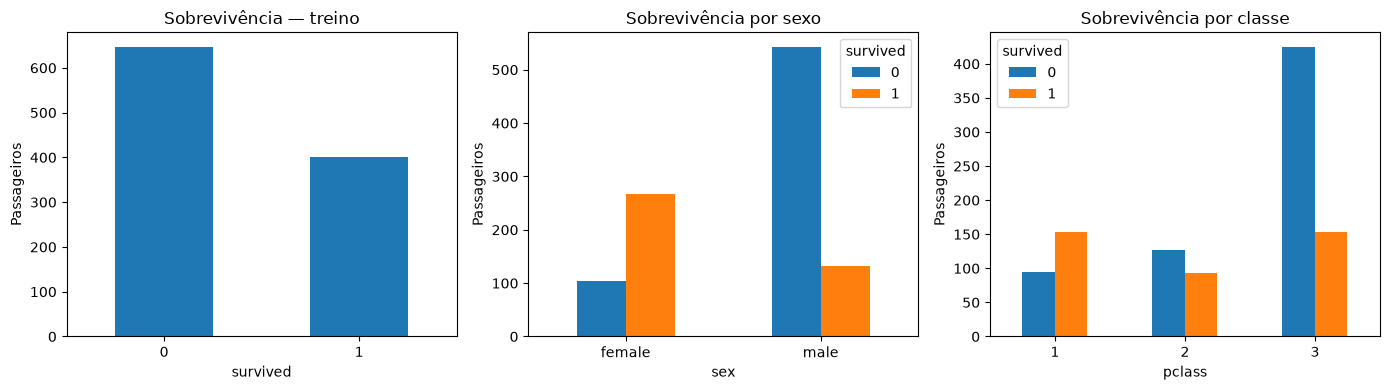

,sex,pclass,passageiros,taxa_sobrevivencia
0,female,1,110,0.972727
1,female,2,84,0.857143
2,female,3,178,0.500000
3,male,1,139,0.338129
4,male,2,136,0.154412
5,male,3,400,0.160000


In [3]:
atributos_remover = ['boat', 'body', 'cabin', 'home.dest', 'name', 'ticket']
X = df.drop(columns=['survived'] + atributos_remover)
y = df['survived'].astype(int)
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
assert set(X_treino.index).isdisjoint(X_teste.index)
folds = list(StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED).split(X_treino, y_treino))
salvar_tabela(pd.DataFrame([
    {'conjunto': nome, 'total': len(alvo), 'não sobreviveu': int((alvo == 0).sum()),
     'sobreviveu': int((alvo == 1).sum()), 'proporção sobreviventes': alvo.mean()}
    for nome, alvo in [('Base', y), ('Treino', y_treino), ('Teste', y_teste)]
]), 'divisao_dados')
eda = X_treino.assign(survived=y_treino)
fig, eixos = plt.subplots(1, 3, figsize=(14, 4))
y_treino.value_counts().sort_index().plot.bar(ax=eixos[0], title='Sobrevivência — treino', rot=0)
pd.crosstab(eda['sex'], eda['survived']).plot.bar(ax=eixos[1], title='Sobrevivência por sexo', rot=0)
pd.crosstab(eda['pclass'], eda['survived']).plot.bar(ax=eixos[2], title='Sobrevivência por classe', rot=0)
for ax in eixos:
    ax.set_ylabel('Passageiros')
salvar_figura('exploracao_treino')
salvar_tabela(eda.groupby(['sex', 'pclass'])['survived'].agg(['count', 'mean']).reset_index().rename(
    columns={'count': 'passageiros', 'mean': 'taxa_sobrevivencia'}), 'padroes_observados_treino')


## 2. KNN Imputer e MissForest
O KNN usa cinco vizinhos, pesos pela distância e padronização ajustada somente no treino.
Depois da imputação, retornei às unidades originais. Para MissForest, usei a alternativa
permitida no enunciado: `IterativeImputer(RandomForestRegressor(...))`, com 60 árvores e até oito rodadas.
É uma **aproximação baseada em florestas**, não uma reprodução exata do algoritmo original
(o critério de parada e o tratamento categórico são diferentes).

Para `embarked` ausente, as três colunas one-hot começam como NaN. Ambos os métodos estimam
seus valores e escolhem o porto com maior escore. Os valores observados permanecem inalterados.
Isso permite comparar os dois métodos também no atributo nominal, sem inventar uma ordem entre portos.
Limitei idade/tarifa imputadas a valores não negativos. O alvo nunca entra na imputação.

A tabela compara dados originalmente observados, somente valores imputados e a coluna completa
após o preenchimento. A distância de Wasserstein mede deslocamentos na distribuição numérica
ela também é dividida pelo desvio padrão observado para comparação entre atributos.
Para o porto, usei distância de variação total entre proporções (0 = iguais, 1 = disjuntas).
Sem conhecer os valores faltantes reais, preservar a distribuição marginal não comprova acerto da imputação.


In [4]:
NUMERICAS = ['pclass', 'age', 'sibsp', 'parch', 'fare']
PORTOS = ['C', 'Q', 'S']
FEATURES = NUMERICAS + ['sex_female'] + [f'embarked_{p}' for p in PORTOS]

class ImputadorTitanic(TransformerMixin, BaseEstimator):
    def __init__(self, metodo='KNN', random_state=42):
        self.metodo = metodo
        self.random_state = random_state

    def codificar(self, X):
        dados = X[NUMERICAS].astype(float).copy()
        dados['sex_female'] = X['sex'].map({'female': 1.0, 'male': 0.0})
        for porto in PORTOS:
            dados[f'embarked_{porto}'] = (X['embarked'] == porto).astype(float)
        dados.loc[X['embarked'].isna(), [f'embarked_{p}' for p in PORTOS]] = np.nan
        return dados[FEATURES].to_numpy()

    def fit(self, X, y=None):
        matriz = self.codificar(X)
        self.n_features_in_ = X.shape[1]
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.convergiu_ = True
        if self.metodo == 'KNN':
            self.scaler_ = StandardScaler().fit(matriz)
            matriz = self.scaler_.transform(matriz)
            self.imputer_ = KNNImputer(n_neighbors=5, weights='distance', keep_empty_features=True)
        elif self.metodo == 'MissForest':
            self.imputer_ = IterativeImputer(
                estimator=RandomForestRegressor(n_estimators=60, min_samples_leaf=2, n_jobs=1,
                                                random_state=self.random_state),
                max_iter=8, tol=0.01, initial_strategy='median',
                skip_complete=False, keep_empty_features=True, random_state=self.random_state
            )
        else:
            raise ValueError(self.metodo)
        with warnings.catch_warnings(record=True) as avisos:
            warnings.simplefilter('always', ConvergenceWarning)
            self.imputer_.fit(matriz)
        self.convergiu_ = not any(issubclass(a.category, ConvergenceWarning) for a in avisos)
        for aviso in avisos:
            if not issubclass(aviso.category, ConvergenceWarning):
                warnings.warn(str(aviso.message), aviso.category)
        return self

    def transform(self, X):
        original = self.codificar(X)
        matriz = self.scaler_.transform(original) if self.metodo == 'KNN' else original
        preenchida = self.imputer_.transform(matriz)
        if self.metodo == 'KNN':
            preenchida = self.scaler_.inverse_transform(preenchida)
        preenchida = np.where(np.isnan(original), preenchida, original)
        for coluna in ['age', 'fare']:
            j = FEATURES.index(coluna)
            preenchida[:, j] = np.maximum(preenchida[:, j], 0)
        faltantes = X['embarked'].isna().to_numpy()
        preenchida[faltantes, -3:] = np.eye(3)[preenchida[faltantes, -3:].argmax(axis=1)]
        return preenchida

    def get_feature_names_out(self, input_features=None):
        return np.asarray(FEATURES, dtype=object)

imputadores, dados_imputados, linhas_dist, linhas_porto, tempos_imputacao = {}, {}, [], [], []
for metodo in ['KNN', 'MissForest']:
    inicio = perf_counter()
    imputador = ImputadorTitanic(metodo, SEED).fit(X_treino)
    dados = pd.DataFrame(imputador.transform(X_treino), columns=FEATURES, index=X_treino.index)
    imputadores[metodo], dados_imputados[metodo] = imputador, dados
    tempos_imputacao.append({'imputacao': metodo, 'tempo_fit_transform_s': perf_counter()-inicio,
        'convergiu': imputador.convergiu_, 'rodadas': getattr(imputador.imputer_, 'n_iter_', np.nan)})
    assert np.isfinite(dados.to_numpy()).all()
    for coluna in ['age', 'fare']:
        observado = X_treino[coluna].dropna()
        falta = X_treino[coluna].isna()
        for grupo, valores in [('Observado', observado), ('Somente imputado', dados.loc[falta, coluna]),
                               ('Após imputação', dados[coluna])]:
            distancia = wasserstein_distance(observado, valores) if len(valores) else np.nan
            linhas_dist.append({'imputacao': metodo, 'atributo': coluna, 'grupo': grupo,
                'n': len(valores), 'media': valores.mean(), 'desvio_padrao': valores.std(),
                'q25': valores.quantile(.25), 'mediana': valores.median(), 'q75': valores.quantile(.75),
                'wasserstein': distancia, 'wasserstein_normalizada': distancia/observado.std()})
        np.testing.assert_allclose(dados.loc[~falta, coluna], X_treino.loc[~falta, coluna])
    portos = pd.Series(np.asarray(PORTOS)[dados.iloc[:, -3:].to_numpy().argmax(axis=1)], index=X_treino.index)
    observado = X_treino['embarked'].value_counts(normalize=True).reindex(PORTOS, fill_value=0)
    for grupo, valores in [('Observado', X_treino['embarked'].dropna()),
                          ('Somente imputado', portos[X_treino['embarked'].isna()]), ('Após imputação', portos)]:
        proporcoes = valores.value_counts(normalize=True).reindex(PORTOS, fill_value=0)
        linhas_porto.append({'imputacao': metodo, 'grupo': grupo, 'n': len(valores),
            **{f'proporcao_{p}': proporcoes[p] for p in PORTOS},
            'variacao_total': abs(proporcoes-observado).sum()/2 if len(valores) else np.nan})

tabela_imputacao = pd.DataFrame(linhas_dist)
tabela_portos = pd.DataFrame(linhas_porto)
salvar_tabela(tabela_imputacao, 'comparacao_imputacao_numerica')
salvar_tabela(tabela_portos, 'comparacao_imputacao_categorica')
salvar_tabela(pd.DataFrame(tempos_imputacao), 'tempo_imputacao')


,imputacao,atributo,grupo,n,media,desvio_padrao,q25,mediana,q75,wasserstein,wasserstein_normalizada
0,KNN,age,Observado,838,29.604320,14.362728,21.000000,28.000000,38.375000,0.000000,0.000000
1,KNN,age,Somente imputado,209,31.859392,14.989370,23.500000,26.900000,39.300000,2.827024,0.196831
2,KNN,age,Após imputação,1047,30.054473,14.510740,21.000000,27.244867,39.000000,0.564325,0.039291
3,KNN,fare,Observado,1046,32.166838,48.915820,7.895800,13.816650,30.923950,0.000000,0.000000
4,KNN,fare,Somente imputado,1,18.029160,NaN,18.029160,18.029160,18.029160,23.993805,0.490512
5,KNN,fare,Após imputação,1047,32.153335,48.894384,7.895800,13.858300,30.847900,0.022917,0.000468
6,MissForest,age,Observado,838,29.604320,14.362728,21.000000,28.000000,38.375000,0.000000,0.000000
7,MissForest,age,Somente imputado,209,29.193547,8.558939,23.834735,28.967958,34.226935,4.714292,0.328231
8,MissForest,age,Após imputação,1047,29.522322,13.403874,21.000000,28.000000,38.000000,0.941057,0.065521
9,MissForest,fare,Observado,1046,32.166838,48.915820,7.895800,13.816650,30.923950,0.000000,0.000000


,imputacao,grupo,n,proporcao_C,proporcao_Q,proporcao_S,variacao_total
0,KNN,Observado,1047,0.204394,0.098376,0.69723,0.0
1,KNN,Somente imputado,0,0.000000,0.000000,0.00000,NaN
2,KNN,Após imputação,1047,0.204394,0.098376,0.69723,0.0
3,MissForest,Observado,1047,0.204394,0.098376,0.69723,0.0
4,MissForest,Somente imputado,0,0.000000,0.000000,0.00000,NaN
5,MissForest,Após imputação,1047,0.204394,0.098376,0.69723,0.0


,imputacao,tempo_fit_transform_s,convergiu,rodadas
0,KNN,0.007316,True,NaN
1,MissForest,0.550487,True,2.0


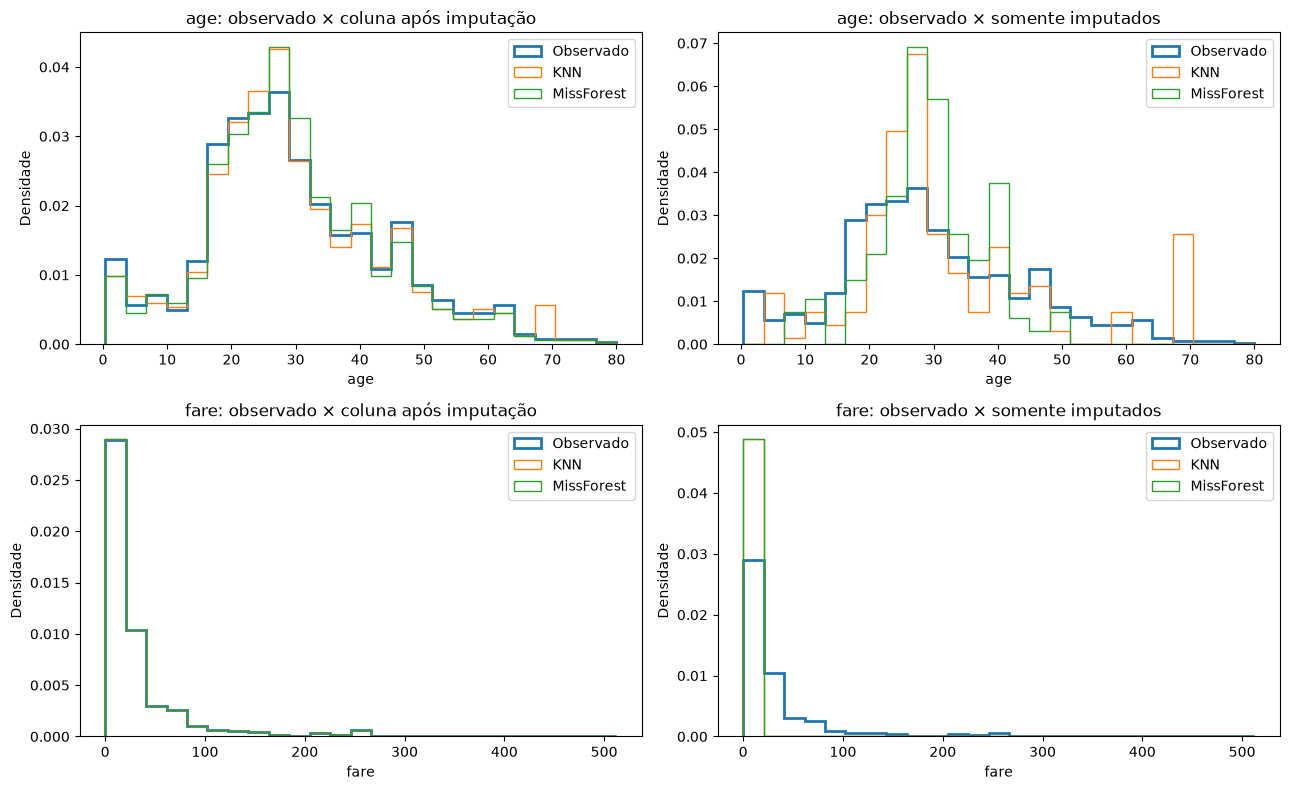

**Preservação marginal numérica:** a menor distância normalizada média foi de **KNN** (0.0199). O resultado não mede a recuperação dos valores reais. Tarifa e porto têm pouquíssimas ausências; suas comparações têm evidência limitada. Ambos os imputadores seguem para a modelagem; a escolha final será justificada pelo F1 de validação.

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for i, atributo in enumerate(['age', 'fare']):
    observado = X_treino[atributo].dropna()
    bins = np.histogram_bin_edges(observado, bins=25)
    axes[i, 0].hist(observado, bins=bins, density=True, histtype='step', linewidth=2, label='Observado')
    axes[i, 1].hist(observado, bins=bins, density=True, histtype='step', linewidth=2, label='Observado')
    for metodo, dados in dados_imputados.items():
        axes[i, 0].hist(dados[atributo], bins=bins, density=True, histtype='step', label=metodo)
        valores = dados.loc[X_treino[atributo].isna(), atributo]
        if len(valores):
            axes[i, 1].hist(valores, bins=bins, density=True, histtype='step', label=metodo)
    axes[i, 0].set_title(f'{atributo}: observado × coluna após imputação')
    axes[i, 1].set_title(f'{atributo}: observado × somente imputados')
    for ax in axes[i]:
        ax.legend(); ax.set_ylabel('Densidade'); ax.set_xlabel(atributo)
salvar_figura('distribuicoes_imputacao')
preservacao = tabela_imputacao.query("grupo == 'Após imputação'").groupby('imputacao')['wasserstein_normalizada'].mean()
display(Markdown(f'**Preservação marginal numérica:** a menor distância normalizada média foi de '
    f'**{preservacao.idxmin()}** ({preservacao.min():.4f}). O resultado não mede a recuperação dos valores reais. '
    'Tarifa e porto têm pouquíssimas ausências; suas comparações têm evidência limitada. '
    'Ambos os imputadores seguem para a modelagem; a escolha final será justificada pelo F1 de validação.'))


## 3. Balanceamento: SMOTE × RandomUnderSampling
A classe minoritária é **sobreviveu (1)**. SMOTE interpola exemplos dessa classe
RandomUnderSampling remove aleatoriamente exemplos da classe majoritária.
Ambos buscam a proporção 1:1 somente no treino. No SMOTE, padronizei temporariamente os atributos
para calcular distâncias e retornei às unidades originais antes de treinar o modelo.

O SMOTE convencional pode gerar valores fracionários em indicadores, classe e contagens:
estes são pontos sintéticos no espaço de atributos, não passageiros literais. Essa é uma limitação
do método escolhido SMOTENC seria uma extensão para dados mistos fora desta comparação.
RandomUnderSampling mantém passageiros reais, mas descarta informação.
As etapas ficam dentro de `imblearn.pipeline.Pipeline`, inclusive em cada fold das buscas:
nem validação nem teste são reamostrados. Os imputadores exploratórios anteriores **não** são
reutilizados já ajustados nas buscas.


,imputacao,balanceamento,etapa,classe_0,classe_1,total,proporcao_classe_1
0,KNN,SMOTE,Antes,647,400,1047,0.382044
1,KNN,SMOTE,Depois,647,647,1294,0.500000
2,KNN,RandomUnderSampling,Antes,647,400,1047,0.382044
3,KNN,RandomUnderSampling,Depois,400,400,800,0.500000
4,MissForest,SMOTE,Antes,647,400,1047,0.382044
5,MissForest,SMOTE,Depois,647,647,1294,0.500000
6,MissForest,RandomUnderSampling,Antes,647,400,1047,0.382044
7,MissForest,RandomUnderSampling,Depois,400,400,800,0.500000


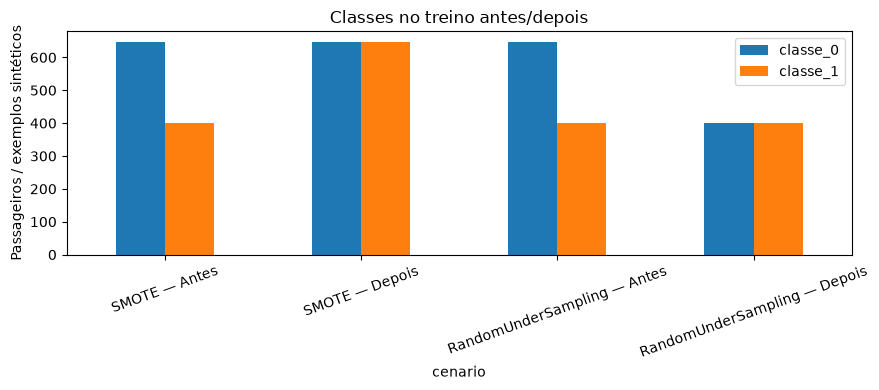

In [6]:
def smote_em_escala(X, y):
    escala = StandardScaler()
    matriz = escala.fit_transform(X)
    X_novo, y_novo = SMOTE(random_state=SEED, k_neighbors=5).fit_resample(matriz, y)
    return escala.inverse_transform(X_novo), y_novo

def criar_balanceador(nome):
    return FunctionSampler(func=smote_em_escala) if nome == 'SMOTE' else RandomUnderSampler(random_state=SEED)

linhas = []
for metodo, dados in dados_imputados.items():
    for tecnica in ['SMOTE', 'RandomUnderSampling']:
        _, alvo = criar_balanceador(tecnica).fit_resample(dados.to_numpy(), y_treino)
        for etapa, valores in [('Antes', y_treino), ('Depois', pd.Series(alvo))]:
            contagem = valores.value_counts()
            linhas.append({'imputacao': metodo, 'balanceamento': tecnica, 'etapa': etapa,
                'classe_0': int(contagem[0]), 'classe_1': int(contagem[1]), 'total': len(valores),
                'proporcao_classe_1': valores.mean()})
        assert (pd.Series(alvo).value_counts().nunique() == 1)
tabela_balanceamento = pd.DataFrame(linhas)
salvar_tabela(tabela_balanceamento, 'comparacao_balanceamento')
grafico = tabela_balanceamento.query("imputacao == 'KNN'").copy()
grafico['cenario'] = grafico['balanceamento'] + ' — ' + grafico['etapa']
grafico.set_index('cenario')[['classe_0', 'classe_1']].plot.bar(rot=20, title='Classes no treino antes/depois')
plt.ylabel('Passageiros / exemplos sintéticos')
salvar_figura('balanceamento_classes')


## 4. Otimização da Árvore de Decisão e do Random Forest
RandomizedSearchCV amostra combinações sem reposição. Optuna/TPE adapta suas sugestões ao histórico
e pode repetir uma combinação. Os dois têm 12 avaliações e o mesmo domínio discreto de parâmetros.
Usei execução sequencial (`n_jobs=1`) nos dois, sem vantagem de paralelismo.

Cada busca começa com seu próprio cache vazio: transformações idênticas de um mesmo fold podem ser
reutilizadas entre candidatos, mas não são compartilhadas entre otimizadores. Os tempos de busca
incluem pré-processamento, validação e gerenciamento do cache o ajuste final é cronometrado à parte.
Assim não cobrei o refit apenas de um otimizador. O desvio padrão reportado é entre três folds,
não um intervalo de confiança nem prova de significância.


In [7]:
ESPACOS = {
    'Árvore de Decisão': {
        'modelo__criterion': ['gini', 'entropy'],
        'modelo__max_depth': [3, 4, 5, 6, 8],
        'modelo__min_samples_split': [2, 5, 10, 20],
        'modelo__min_samples_leaf': [2, 5, 10],
    },
    'Random Forest': {
        'modelo__n_estimators': [80, 140, 200],
        'modelo__max_depth': [4, 6, 8, None],
        'modelo__min_samples_split': [2, 5, 10],
        'modelo__min_samples_leaf': [1, 2, 5],
        'modelo__max_features': ['sqrt', 'log2', 0.8],
        'modelo__criterion': ['gini', 'entropy'],
    },
}

def criar_pipeline(imputacao, balanceamento, modelo, memoria=None):
    estimador = (DecisionTreeClassifier(random_state=SEED) if modelo == 'Árvore de Decisão'
                 else RandomForestClassifier(random_state=SEED, n_jobs=1))
    return Pipeline([
        ('imputacao', ImputadorTitanic(imputacao, SEED)),
        ('balanceamento', criar_balanceador(balanceamento)),
        ('modelo', estimador),
    ], memory=memoria)

resultados_busca, modelos_ajustados, historicos = [], {}, []
for imputacao in ['KNN', 'MissForest']:
    for balanceamento in ['SMOTE', 'RandomUnderSampling']:
        for modelo in ESPACOS:
            for otimizador in ['Random Search', 'Optuna TPE']:
                chave = (imputacao, balanceamento, modelo, otimizador)
                inicio = perf_counter()
                with TemporaryDirectory(prefix='titanic-list03-') as pasta_cache:
                    pipeline = criar_pipeline(imputacao, balanceamento, modelo, Memory(pasta_cache, verbose=0))
                    if otimizador == 'Random Search':
                        busca = RandomizedSearchCV(pipeline, ESPACOS[modelo], n_iter=N_CANDIDATOS,
                            scoring='f1', cv=folds, refit=False, n_jobs=1, random_state=SEED,
                            error_score='raise', return_train_score=False)
                        busca.fit(X_treino, y_treino)
                        params, media = busca.best_params_, busca.best_score_
                        desvio = busca.cv_results_['std_test_score'][busca.best_index_]
                        for j, p in enumerate(busca.cv_results_['params']):
                            historicos.append(dict(zip(['imputacao','balanceamento','modelo','otimizador'], chave),
                                tentativa=j, f1_cv=busca.cv_results_['mean_test_score'][j],
                                parametros=json.dumps(p, ensure_ascii=False)))
                    else:
                        def objetivo(trial):
                            p = {nome: trial.suggest_categorical(nome, valores) for nome, valores in ESPACOS[modelo].items()}
                            notas = cross_val_score(clone(pipeline).set_params(**p), X_treino, y_treino,
                                                    cv=folds, scoring='f1', n_jobs=1, error_score='raise')
                            trial.set_user_attr('std_f1', float(notas.std()))
                            return float(notas.mean())
                        estudo = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=4))
                        estudo.optimize(objetivo, n_trials=N_CANDIDATOS, n_jobs=1)
                        params, media = estudo.best_params, estudo.best_value
                        desvio = estudo.best_trial.user_attrs['std_f1']
                        for trial in estudo.trials:
                            historicos.append(dict(zip(['imputacao','balanceamento','modelo','otimizador'], chave),
                                tentativa=trial.number, f1_cv=trial.value,
                                parametros=json.dumps(trial.params, ensure_ascii=False)))
                tempo_busca = perf_counter() - inicio
                inicio_refit = perf_counter()
                final = criar_pipeline(imputacao, balanceamento, modelo).set_params(**params)
                final.fit(X_treino, y_treino)
                tempo_refit = perf_counter() - inicio_refit
                modelos_ajustados[chave] = final
                resultados_busca.append(dict(zip(['imputacao','balanceamento','modelo','otimizador'], chave),
                    f1_cv=media, std_f1_cv=desvio, tempo_busca_s=tempo_busca, tempo_refit_s=tempo_refit,
                    candidatos=N_CANDIDATOS, imputacao_convergiu=final.named_steps['imputacao'].convergiu_,
                    parametros=json.dumps(params, ensure_ascii=False)))
                print(f'{len(resultados_busca):02d}/16 | {chave} | F1 CV={media:.4f} | busca={tempo_busca:.1f}s', flush=True)

tabela_buscas = pd.DataFrame(resultados_busca)
salvar_tabela(tabela_buscas, 'hiperparametros_otimizadores')
pd.DataFrame(historicos).to_csv(SAIDA / 'historico_buscas.csv', index=False)
# Seleção congelada antes de qualquer previsão ou métrica no teste.
melhor_cv = tabela_buscas.sort_values(['f1_cv', 'tempo_busca_s'], ascending=[False, True]).iloc[0]
chave_escolhida = tuple(melhor_cv[c] for c in ['imputacao','balanceamento','modelo','otimizador'])
melhor_por_modelo = {nome: tabela_buscas[tabela_buscas['modelo'] == nome].sort_values(
    ['f1_cv','tempo_busca_s'], ascending=[False, True]).iloc[0] for nome in ESPACOS}
print('Configuração adotada, escolhida somente pela validação:', chave_escolhida)


01/16 | ('KNN', 'SMOTE', 'Árvore de Decisão', 'Random Search') | F1 CV=0.7408 | busca=0.2s


02/16 | ('KNN', 'SMOTE', 'Árvore de Decisão', 'Optuna TPE') | F1 CV=0.7320 | busca=0.2s


03/16 | ('KNN', 'SMOTE', 'Random Forest', 'Random Search') | F1 CV=0.7419 | busca=3.0s


04/16 | ('KNN', 'SMOTE', 'Random Forest', 'Optuna TPE') | F1 CV=0.7465 | busca=3.3s


05/16 | ('KNN', 'RandomUnderSampling', 'Árvore de Decisão', 'Random Search') | F1 CV=0.7277 | busca=0.2s


...

14/16 | ('MissForest', 'RandomUnderSampling', 'Árvore de Decisão', 'Optuna TPE') | F1 CV=0.7283 | busca=4.8s


15/16 | ('MissForest', 'RandomUnderSampling', 'Random Forest', 'Random Search') | F1 CV=0.7342 | busca=7.2s


16/16 | ('MissForest', 'RandomUnderSampling', 'Random Forest', 'Optuna TPE') | F1 CV=0.7307 | busca=7.7s


,imputacao,balanceamento,modelo,otimizador,f1_cv,std_f1_cv,tempo_busca_s,tempo_refit_s,candidatos,imputacao_convergiu,parametros
0,KNN,SMOTE,Árvore de Decisão,Random Search,0.740834,0.009599,0.239972,0.007868,12,True,"{""modelo__min_samples_split"": 10, ""modelo__min_samples_leaf"": 5, ""modelo__max_depth"": 4, ""modelo__criterion"": ""gini""}"
1,KNN,SMOTE,Árvore de Decisão,Optuna TPE,0.732023,0.002904,0.242431,0.007638,12,True,"{""modelo__criterion"": ""gini"", ""modelo__max_depth"": 5, ""modelo__min_samples_split"": 5, ""modelo__min_samples_leaf"": 5}"
2,KNN,SMOTE,Random Forest,Random Search,0.741919,0.007479,3.047013,0.117442,12,True,"{""modelo__n_estimators"": 200, ""modelo__min_samples_split"": 10, ""modelo__min_samples_leaf"": 5, ""modelo__max_features"": ""sqrt"", ""modelo__max_depth"": null, ""mo..."
3,KNN,SMOTE,Random Forest,Optuna TPE,0.746531,0.007966,3.324648,0.113278,12,True,"{""modelo__n_estimators"": 200, ""modelo__max_depth"": 8, ""modelo__min_samples_split"": 2, ""modelo__min_samples_leaf"": 1, ""modelo__max_features"": ""log2"", ""modelo..."
4,KNN,RandomUnderSampling,Árvore de Decisão,Random Search,0.727667,0.015161,0.229535,0.006299,12,True,"{""modelo__min_samples_split"": 10, ""modelo__min_samples_leaf"": 2, ""modelo__max_depth"": 3, ""modelo__criterion"": ""entropy""}"
5,KNN,RandomUnderSampling,Árvore de Decisão,Optuna TPE,0.727667,0.015161,0.235622,0.006224,12,True,"{""modelo__criterion"": ""entropy"", ""modelo__max_depth"": 3, ""modelo__min_samples_split"": 2, ""modelo__min_samples_leaf"": 2}"
6,KNN,RandomUnderSampling,Random Forest,Random Search,0.731828,0.012405,2.613366,0.063742,12,True,"{""modelo__n_estimators"": 140, ""modelo__min_samples_split"": 10, ""modelo__min_samples_leaf"": 2, ""modelo__max_features"": ""log2"", ""modelo__max_depth"": 6, ""model..."
7,KNN,RandomUnderSampling,Random Forest,Optuna TPE,0.737861,0.006977,2.315888,0.041221,12,True,"{""modelo__n_estimators"": 80, ""modelo__max_depth"": 8, ""modelo__min_samples_split"": 2, ""modelo__min_samples_leaf"": 1, ""modelo__max_features"": ""sqrt"", ""modelo_..."
8,MissForest,SMOTE,Árvore de Decisão,Random Search,0.737372,0.003791,4.675227,0.569765,12,True,"{""modelo__min_samples_split"": 10, ""modelo__min_samples_leaf"": 5, ""modelo__max_depth"": 4, ""modelo__criterion"": ""gini""}"
9,MissForest,SMOTE,Árvore de Decisão,Optuna TPE,0.737372,0.003791,4.688622,0.562900,12,True,"{""modelo__criterion"": ""gini"", ""modelo__max_depth"": 4, ""modelo__min_samples_split"": 10, ""modelo__min_samples_leaf"": 5}"


Configuração adotada, escolhida somente pela validação: ('MissForest', 'SMOTE', 'Random Forest', 'Optuna TPE')


## 5. Avaliação final e comparações
Todos os modelos abaixo preveem os mesmos 262 passageiros de teste, na proporção original de classes.
Acurácia mede acertos gerais. Precisão, recall e F1 usam sobreviventes como classe positiva
também mostrei F1 macro para dar o mesmo peso às duas classes. O limiar é o padrão do classificador.
O melhor resultado no teste não substitui a escolha já feita na validação.


,imputacao,balanceamento,modelo,otimizador,acuracia,precisao,recall,f1,f1_macro
0,KNN,SMOTE,Árvore de Decisão,Random Search,0.824427,0.745455,0.82,0.780952,0.817228
1,KNN,SMOTE,Árvore de Decisão,Optuna TPE,0.816794,0.736364,0.81,0.771429,0.809281
2,KNN,SMOTE,Random Forest,Random Search,0.828244,0.766990,0.79,0.778325,0.819069
3,KNN,SMOTE,Random Forest,Optuna TPE,0.832061,0.774510,0.79,0.782178,0.822766
4,KNN,RandomUnderSampling,Árvore de Decisão,Random Search,0.839695,0.815217,0.75,0.781250,0.827372
5,KNN,RandomUnderSampling,Árvore de Decisão,Optuna TPE,0.839695,0.815217,0.75,0.781250,0.827372
6,KNN,RandomUnderSampling,Random Forest,Random Search,0.828244,0.757009,0.81,0.782609,0.820326
7,KNN,RandomUnderSampling,Random Forest,Optuna TPE,0.812977,0.738318,0.79,0.763285,0.804355
8,MissForest,SMOTE,Árvore de Decisão,Random Search,0.812977,0.725664,0.82,0.769953,0.806198
9,MissForest,SMOTE,Árvore de Decisão,Optuna TPE,0.812977,0.725664,0.82,0.769953,0.806198


,imputacao,balanceamento,modelo,otimizador,f1_cv,std_f1_cv,tempo_busca_s,tempo_refit_s,candidatos,imputacao_convergiu,parametros,acuracia,precisao,recall,f1,f1_macro
0,KNN,SMOTE,Árvore de Decisão,Random Search,0.740834,0.009599,0.239972,0.007868,12,True,"{""modelo__min_samples_split"": 10, ""modelo__min_samples_leaf"": 5, ""modelo__max_depth"": 4, ""modelo__criterion"": ""gini""}",0.824427,0.745455,0.82,0.780952,0.817228
1,KNN,SMOTE,Árvore de Decisão,Optuna TPE,0.732023,0.002904,0.242431,0.007638,12,True,"{""modelo__criterion"": ""gini"", ""modelo__max_depth"": 5, ""modelo__min_samples_split"": 5, ""modelo__min_samples_leaf"": 5}",0.816794,0.736364,0.81,0.771429,0.809281
2,KNN,SMOTE,Random Forest,Random Search,0.741919,0.007479,3.047013,0.117442,12,True,"{""modelo__n_estimators"": 200, ""modelo__min_samples_split"": 10, ""modelo__min_samples_leaf"": 5, ""modelo__max_features"": ""sqrt"", ""modelo__max_depth"": null, ""mo...",0.828244,0.766990,0.79,0.778325,0.819069
3,KNN,SMOTE,Random Forest,Optuna TPE,0.746531,0.007966,3.324648,0.113278,12,True,"{""modelo__n_estimators"": 200, ""modelo__max_depth"": 8, ""modelo__min_samples_split"": 2, ""modelo__min_samples_leaf"": 1, ""modelo__max_features"": ""log2"", ""modelo...",0.832061,0.774510,0.79,0.782178,0.822766
4,KNN,RandomUnderSampling,Árvore de Decisão,Random Search,0.727667,0.015161,0.229535,0.006299,12,True,"{""modelo__min_samples_split"": 10, ""modelo__min_samples_leaf"": 2, ""modelo__max_depth"": 3, ""modelo__criterion"": ""entropy""}",0.839695,0.815217,0.75,0.781250,0.827372
5,KNN,RandomUnderSampling,Árvore de Decisão,Optuna TPE,0.727667,0.015161,0.235622,0.006224,12,True,"{""modelo__criterion"": ""entropy"", ""modelo__max_depth"": 3, ""modelo__min_samples_split"": 2, ""modelo__min_samples_leaf"": 2}",0.839695,0.815217,0.75,0.781250,0.827372
6,KNN,RandomUnderSampling,Random Forest,Random Search,0.731828,0.012405,2.613366,0.063742,12,True,"{""modelo__n_estimators"": 140, ""modelo__min_samples_split"": 10, ""modelo__min_samples_leaf"": 2, ""modelo__max_features"": ""log2"", ""modelo__max_depth"": 6, ""model...",0.828244,0.757009,0.81,0.782609,0.820326
7,KNN,RandomUnderSampling,Random Forest,Optuna TPE,0.737861,0.006977,2.315888,0.041221,12,True,"{""modelo__n_estimators"": 80, ""modelo__max_depth"": 8, ""modelo__min_samples_split"": 2, ""modelo__min_samples_leaf"": 1, ""modelo__max_features"": ""sqrt"", ""modelo_...",0.812977,0.738318,0.79,0.763285,0.804355
8,MissForest,SMOTE,Árvore de Decisão,Random Search,0.737372,0.003791,4.675227,0.569765,12,True,"{""modelo__min_samples_split"": 10, ""modelo__min_samples_leaf"": 5, ""modelo__max_depth"": 4, ""modelo__criterion"": ""gini""}",0.812977,0.725664,0.82,0.769953,0.806198
9,MissForest,SMOTE,Árvore de Decisão,Optuna TPE,0.737372,0.003791,4.688622,0.562900,12,True,"{""modelo__criterion"": ""gini"", ""modelo__max_depth"": 4, ""modelo__min_samples_split"": 10, ""modelo__min_samples_leaf"": 5}",0.812977,0.725664,0.82,0.769953,0.806198


,modelo,f1_cv,acuracia,precisao,recall,f1,tempo_busca_s
0,Random Forest,0.739941,0.826813,0.761775,0.79500,0.777971,5.132497
1,Árvore de Decisão,0.732438,0.826336,0.769916,0.78375,0.775147,2.487261


,otimizador,f1_cv,acuracia,precisao,recall,f1,tempo_busca_s
0,Optuna TPE,0.736692,0.824905,0.764284,0.78625,0.774239,3.827198
1,Random Search,0.735687,0.828244,0.767406,0.79250,0.778880,3.792561


,imputacao,f1_cv,acuracia,precisao,recall,f1,tempo_busca_s
0,KNN,0.735791,0.827767,0.768635,0.78875,0.777660,1.531059
1,MissForest,0.736588,0.825382,0.763056,0.79000,0.775459,6.088699


,balanceamento,f1_cv,acuracia,precisao,recall,f1,tempo_busca_s
0,RandomUnderSampling,0.730816,0.828244,0.779503,0.77000,0.773959,3.740278
1,SMOTE,0.741563,0.824905,0.752188,0.80875,0.779160,3.879480


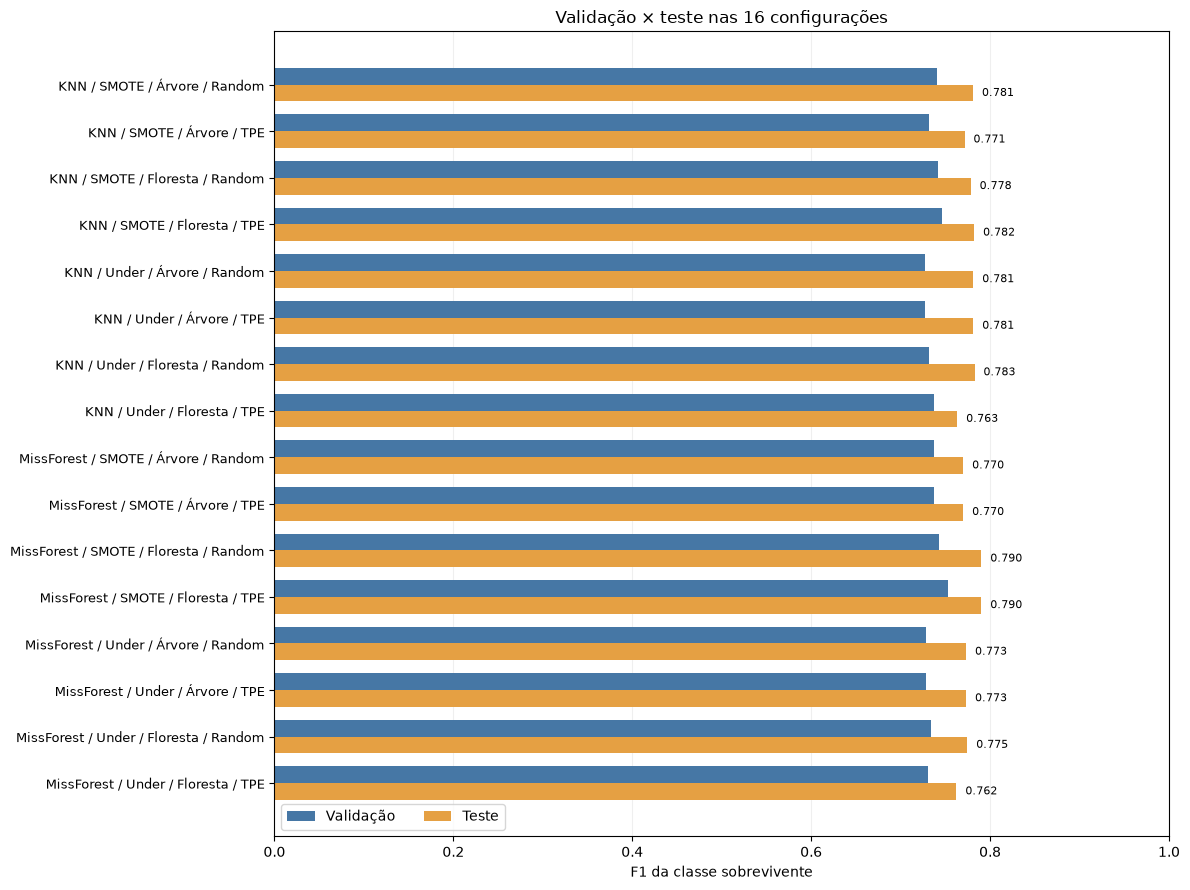

Árvore de Decisão ('KNN', 'SMOTE', 'Árvore de Decisão', 'Random Search')
                precision    recall  f1-score   support

Não sobreviveu       0.88      0.83      0.85       162
    Sobreviveu       0.75      0.82      0.78       100

      accuracy                           0.82       262
     macro avg       0.81      0.82      0.82       262
  weighted avg       0.83      0.82      0.83       262

Random Forest ('MissForest', 'SMOTE', 'Random Forest', 'Optuna TPE')
                precision    recall  f1-score   support

Não sobreviveu       0.88      0.85      0.87       162
    Sobreviveu       0.77      0.81      0.79       100

      accuracy                           0.84       262
     macro avg       0.83      0.83      0.83       262
  weighted avg       0.84      0.84      0.84       262



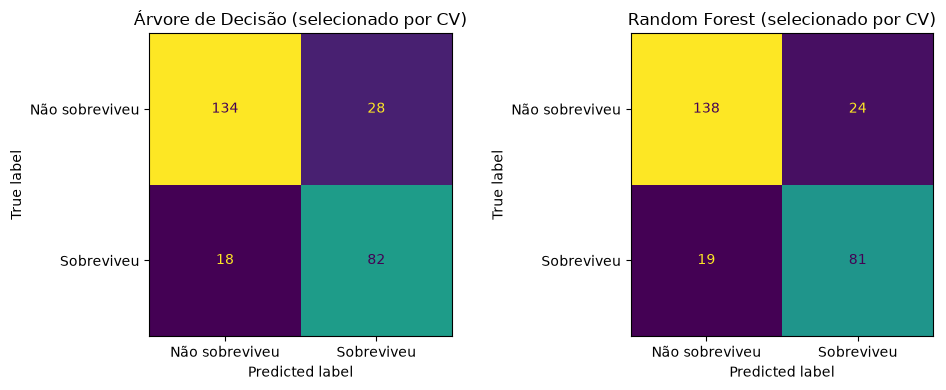

In [8]:
linhas_metricas, previsoes = [], {}
for chave, pipeline in modelos_ajustados.items():
    pred = pipeline.predict(X_teste)
    assert len(pred) == len(y_teste) and len(y_teste) == 262
    previsoes[chave] = pred
    linhas_metricas.append(dict(zip(['imputacao','balanceamento','modelo','otimizador'], chave),
        acuracia=accuracy_score(y_teste, pred), precisao=precision_score(y_teste, pred, zero_division=0),
        recall=recall_score(y_teste, pred, zero_division=0), f1=f1_score(y_teste, pred, zero_division=0),
        f1_macro=f1_score(y_teste, pred, average='macro', zero_division=0)))
tabela_metricas = pd.DataFrame(linhas_metricas)
salvar_tabela(tabela_metricas, 'metricas_teste')
consolidada = tabela_buscas.merge(tabela_metricas, on=['imputacao','balanceamento','modelo','otimizador'], validate='one_to_one')
salvar_tabela(consolidada, 'resultados_consolidados')
pd.DataFrame({'indice_original': X_teste.index, 'real': y_teste.to_numpy(),
    **{' | '.join(chave): valores for chave, valores in previsoes.items()}}).to_csv(SAIDA / 'previsoes_teste.csv', index=False)

resumos = {}
for fator in ['modelo', 'otimizador', 'imputacao', 'balanceamento']:
    resumo = consolidada.groupby(fator)[['f1_cv','acuracia','precisao','recall','f1','tempo_busca_s']].mean().reset_index()
    resumos[fator] = resumo
    salvar_tabela(resumo, f'resumo_{fator}')

fig, ax = plt.subplots(figsize=(12, 9))
# Rótulos curtos e barras horizontais preservam espaço para comparar os valores.
rotulos = (consolidada['imputacao'] + ' / '
    + consolidada['balanceamento'].replace({'RandomUnderSampling': 'Under'}) + ' / '
    + consolidada['modelo'].replace({'Árvore de Decisão': 'Árvore', 'Random Forest': 'Floresta'}) + ' / '
    + consolidada['otimizador'].replace({'Random Search': 'Random', 'Optuna TPE': 'TPE'}))
posicoes = np.arange(len(consolidada))
ax.barh(posicoes-.18, consolidada['f1_cv'], height=.36, label='Validação', color='#4677a5')
ax.barh(posicoes+.18, consolidada['f1'], height=.36, label='Teste', color='#e5a043')
for i, valor in enumerate(consolidada['f1']):
    ax.text(valor+.01, i+.18, f'{valor:.3f}', va='center', fontsize=8)
ax.set_yticks(posicoes, rotulos, fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel('F1 da classe sobrevivente')
ax.set_title('Validação × teste nas 16 configurações')
ax.grid(axis='x', alpha=.2)
ax.set_axisbelow(True)
ax.legend(loc='lower left', ncol=2)
salvar_figura('f1_validacao_teste')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
chaves_por_modelo = {}
for ax, (nome, linha) in zip(axes, melhor_por_modelo.items()):
    chave = tuple(linha[c] for c in ['imputacao','balanceamento','modelo','otimizador'])
    chaves_por_modelo[nome] = chave
    ConfusionMatrixDisplay.from_predictions(y_teste, previsoes[chave], display_labels=['Não sobreviveu','Sobreviveu'],
                                           ax=ax, colorbar=False)
    ax.set_title(nome + ' (selecionado por CV)')
    print(nome, chave)
    print(classification_report(y_teste, previsoes[chave], target_names=['Não sobreviveu', 'Sobreviveu'], zero_division=0))
salvar_figura('matrizes_confusao')


In [9]:
# Incerteza da diferença entre os dois modelos selecionados por CV.
# Bootstrap pareado: mesmos índices para os dois, estratificado por classe.
rng = np.random.default_rng(SEED)
alvo = y_teste.to_numpy()
idx0, idx1 = np.flatnonzero(alvo == 0), np.flatnonzero(alvo == 1)
pred_arvore = previsoes[chaves_por_modelo['Árvore de Decisão']]
pred_floresta = previsoes[chaves_por_modelo['Random Forest']]
diferencas = []
for _ in range(1000):
    indices = np.concatenate([rng.choice(idx0, len(idx0), replace=True), rng.choice(idx1, len(idx1), replace=True)])
    diferencas.append(f1_score(alvo[indices], pred_floresta[indices], zero_division=0)
                     - f1_score(alvo[indices], pred_arvore[indices], zero_division=0))
limites = np.quantile(diferencas, [.025, .975])
delta = f1_score(alvo, pred_floresta)-f1_score(alvo, pred_arvore)
salvar_tabela(pd.DataFrame([{'comparacao': 'Random Forest − Árvore', 'diferenca_f1_teste': delta,
    'bootstrap_percentil_2.5': limites[0], 'bootstrap_percentil_97.5': limites[1]}]), 'incerteza_modelos')
display(Markdown('O intervalo bootstrap é exploratório e condicionado a este treino/teste. '
    'Não incorpora variabilidade de treinamento nem dependência entre familiares; não substitui '
    'validação aninhada/repetida ou um teste externo independente.'))


,comparacao,diferenca_f1_teste,bootstrap_percentil_2.5,bootstrap_percentil_97.5
0,Random Forest − Árvore,0.009292,-0.034268,0.053954


O intervalo bootstrap é exploratório e condicionado a este treino/teste. Não incorpora variabilidade de treinamento nem dependência entre familiares; não substitui validação aninhada/repetida ou um teste externo independente.

## 6. Regras e padrões de sobrevivência/mortalidade
Extraí regras da **árvore otimizada escolhida pela validação**, não de uma árvore padrão.
Os atributos estão nas unidades originais: idade em anos, tarifa na escala da base,
`sex_female > 0.5` indica mulher e `embarked_C > 0.5` indica embarque em C nos dados reais.
Os limiares exatos podem ser fracionários, especialmente com SMOTE.

O gráfico mostra os três primeiros níveis para facilitar a leitura. As regras de todas as folhas
estão abaixo e no TXT, e um SVG mostra a árvore completa. As contagens da árvore correspondem
ao treino balanceado a tabela por folha usa passageiros originais do treino, sem exemplos sintéticos.
Taxas de sobrevivência nessas folhas são descritivas do treino, não estimativas imparciais de desempenho.


Árvore escolhida: ('KNN', 'SMOTE', 'Árvore de Decisão', 'Random Search')
|--- sex_female <= 0.003
|   |--- age <= 9.492
|   |   |--- sibsp <= 2.500
|   |   |   |--- pclass <= 2.829
|   |   |   |   |--- weights: [0.000, 16.000] class: 1
|   |   |   |--- pclass >  2.829
|   |   |   |   |--- weights: [5.000, 16.000] class: 1
|   |   |--- sibsp >  2.500
|   |   |   |--- age <= 3.500
|   |   |   |   |--- weights: [5.000, 1.000] class: 0
|   |   |   |--- age >  3.500
|   |   |   |   |--- weights: [10.000, 0.000] class: 0
|   |--- age >  9.492
|   |   |--- pclass <= 1.500
|   |   |   |--- age <= 45.498
|   |   |   |   |--- weights: [49.000, 57.000] class: 1
|   |   |   |--- age >  45.498
|   |   |   |   |--- weights: [43.000, 13.000] class: 0
|   |   |--- pclass >  1.500
|   |   |   |--- age <= 32.250
|   |   |   |   |--- weights: [283.000, 76.000] class: 0
|   |   |   |--- age >  32.250
|   |   |   |   |--- weights: [148.000, 14.000] class: 0
|--- sex_female >  0.003
|   |--- pclass <= 2.985

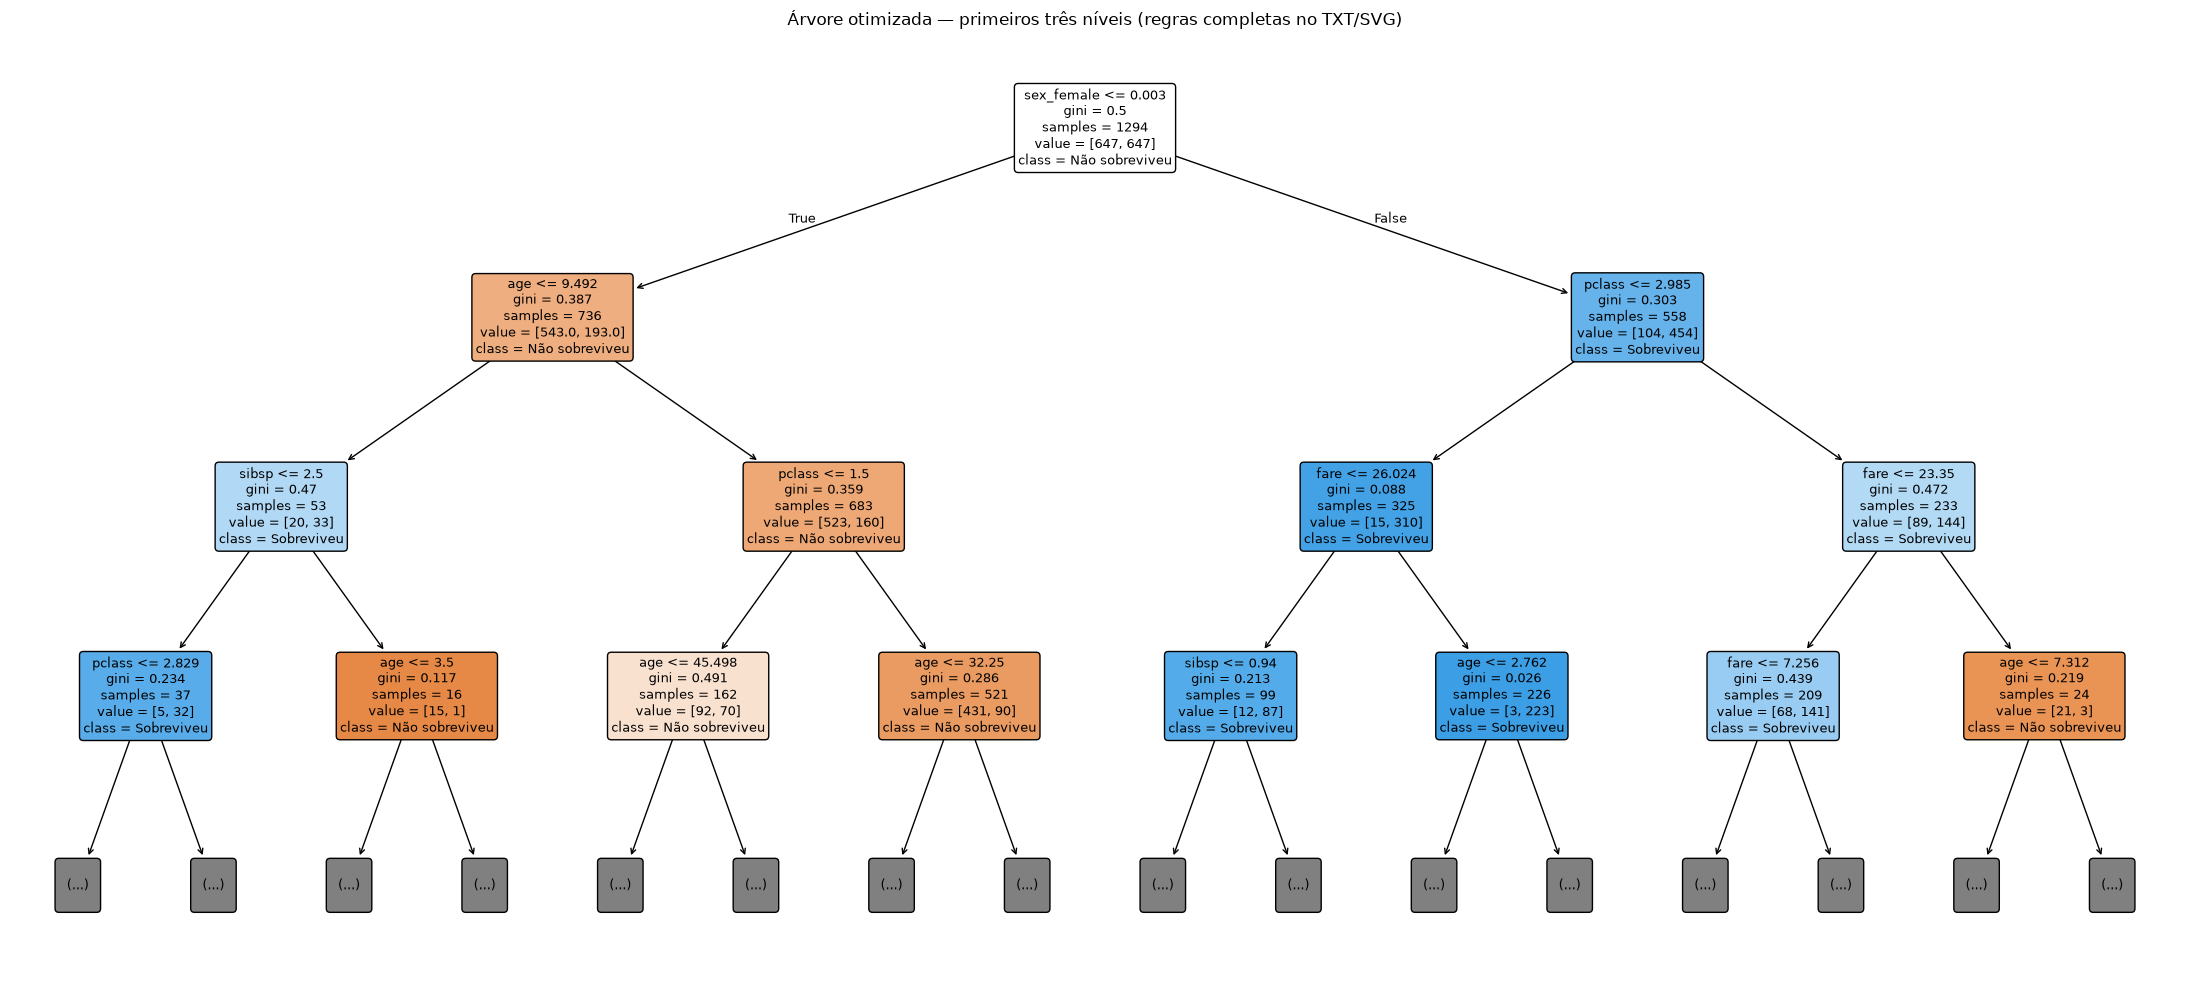

,folha,passageiros,taxa_sobrevivencia,regra,predicao_arvore
6,14,335,0.155224,sex_female <= 0.003 E age > 9.492 E pclass > 1.500 E age <= 32.250,0
7,15,161,0.080745,sex_female <= 0.003 E age > 9.492 E pclass > 1.500 E age > 32.250,0
13,27,145,0.537931,sex_female > 0.003 E pclass > 2.985 E fare <= 23.350 E fare > 7.256,1
11,23,130,0.984615,sex_female > 0.003 E pclass <= 2.985 E fare > 26.024 E age > 2.762,1
4,11,83,0.409639,sex_female <= 0.003 E age > 9.492 E pclass <= 1.500 E age <= 45.498,1
5,12,53,0.188679,sex_female <= 0.003 E age > 9.492 E pclass <= 1.500 E age > 45.498,0
8,19,40,0.850000,sex_female > 0.003 E pclass <= 2.985 E fare <= 26.024 E sibsp <= 0.940,1
9,20,21,0.714286,sex_female > 0.003 E pclass <= 2.985 E fare <= 26.024 E sibsp > 0.940,1
15,30,18,0.055556,sex_female > 0.003 E pclass > 2.985 E fare > 23.350 E age > 7.312,0
1,5,16,0.687500,sex_female <= 0.003 E age <= 9.492 E sibsp <= 2.500 E pclass > 2.829,1


In [10]:
chave_arvore = chaves_por_modelo['Árvore de Decisão']
pipeline_arvore = modelos_ajustados[chave_arvore]
arvore = pipeline_arvore.named_steps['modelo']
regras = export_text(arvore, feature_names=FEATURES, max_depth=arvore.get_depth(), decimals=3, show_weights=True)
print('Árvore escolhida:', chave_arvore)
print(regras)
(SAIDA / 'regras_arvore.txt').write_text(regras, encoding='utf-8')
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(arvore, feature_names=FEATURES, class_names=['Não sobreviveu','Sobreviveu'],
          filled=True, rounded=True, max_depth=3, fontsize=9, ax=ax)
ax.set_title('Árvore otimizada — primeiros três níveis (regras completas no TXT/SVG)')
salvar_figura('arvore_primeiros_niveis')
fig, ax = plt.subplots(figsize=(max(20, arvore.get_n_leaves()*.9), max(10, (arvore.get_depth()+1)*1.4)))
plot_tree(arvore, feature_names=FEATURES, class_names=['Não sobreviveu','Sobreviveu'],
          filled=True, rounded=True, fontsize=8, ax=ax)
fig.savefig(SAIDA / 'arvore_completa.svg', bbox_inches='tight')
plt.close(fig)

caminhos = {}
def percorrer(no=0, condicoes=()):
    estrutura = arvore.tree_
    if estrutura.children_left[no] == estrutura.children_right[no]:
        caminhos[no] = ' E '.join(condicoes) or 'Todos'
        return
    atributo = FEATURES[estrutura.feature[no]]
    limiar = estrutura.threshold[no]
    percorrer(estrutura.children_left[no], condicoes + (f'{atributo} <= {limiar:.3f}',))
    percorrer(estrutura.children_right[no], condicoes + (f'{atributo} > {limiar:.3f}',))
percorrer()
folhas = arvore.apply(pipeline_arvore.named_steps['imputacao'].transform(X_treino))
tabela_folhas = pd.DataFrame({'folha': folhas, 'sobreviveu': y_treino.to_numpy()}).groupby('folha')['sobreviveu'].agg(
    passageiros='count', taxa_sobrevivencia='mean').reset_index()
tabela_folhas['regra'] = tabela_folhas['folha'].map(caminhos)
tabela_folhas['predicao_arvore'] = [int(arvore.classes_[arvore.tree_.value[no][0].argmax()]) for no in tabela_folhas['folha']]
salvar_tabela(tabela_folhas.sort_values('passageiros', ascending=False), 'padroes_regras_arvore')


## 7. Conclusão baseada nos resultados executados
As médias abaixo resumem as configurações cruzadas de maneira descritiva não são novas avaliações
independentes. Diferenças de hiperparâmetros não demonstram, por si só, significância estatística.


In [11]:
linha_final = consolidada.loc[(consolidada[['imputacao','balanceamento','modelo','otimizador']] == pd.Series(
    chave_escolhida, index=['imputacao','balanceamento','modelo','otimizador'])).all(axis=1)].iloc[0]
linhas_selecionadas = {nome: consolidada.loc[(consolidada[['imputacao','balanceamento','modelo','otimizador']] == pd.Series(
    chave, index=['imputacao','balanceamento','modelo','otimizador'])).all(axis=1)].iloc[0] for nome, chave in chaves_por_modelo.items()}
a, f = linhas_selecionadas['Árvore de Decisão'], linhas_selecionadas['Random Forest']
melhor_observado = 'Random Forest' if f['f1'] > a['f1'] else ('Árvore de Decisão' if a['f1'] > f['f1'] else 'empate')
imp = resumos['imputacao'].set_index('imputacao')
bal = resumos['balanceamento'].set_index('balanceamento')
opt = resumos['otimizador'].set_index('otimizador')
pares = tabela_buscas.pivot(index=['imputacao','balanceamento','modelo'], columns='otimizador', values='parametros')
# Compara dicionários, sem considerar a ordem das chaves na serialização JSON.
qtd_parametros_diferentes = sum(
    json.loads(a) != json.loads(b)
    for a, b in zip(pares['Random Search'], pares['Optuna TPE'])
)
rapido = opt['tempo_busca_s'].idxmin()
qualidade = opt['f1_cv'].idxmax()
intervalo_texto = ('inclui zero, portanto não sustenta uma vantagem clara nesta amostra' if limites[0] <= 0 <= limites[1]
                   else 'não inclui zero nesta amostra, mas é condicionado à divisão e aos modelos ajustados')
taxa_sexo = eda.groupby('sex')['survived'].mean()
taxa_classe = eda.groupby('pclass')['survived'].mean()
conclusao = f"""
**Configuração adotada.** Pelo maior F1 médio na validação, adotamos **{' + '.join(chave_escolhida)}**
(F1 CV = {linha_final['f1_cv']:.3f}, desvio entre folds = {linha_final['std_f1_cv']:.3f}).
No teste, obteve acurácia {linha_final['acuracia']:.3f}, precisão {linha_final['precisao']:.3f},
recall {linha_final['recall']:.3f} e F1 {linha_final['f1']:.3f}. O imputador {chave_escolhida[0]}
foi escolhido pela qualidade preditiva na validação, considerando conjuntamente balanceamento e modelo;
a menor mudança marginal isolada não foi usada como substituto dessa avaliação.

**Árvore × floresta (4.b).** Entre as configurações selecionadas por validação para cada família,
a árvore obteve F1 de teste {a['f1']:.3f} e acurácia {a['acuracia']:.3f}; a floresta,
F1 {f['f1']:.3f} e acurácia {f['acuracia']:.3f}. O melhor F1 observado foi de **{melhor_observado}**.
A diferença floresta − árvore foi {delta:.3f}, com intervalo bootstrap de 95%
[{limites[0]:.3f}, {limites[1]:.3f}], que {intervalo_texto}.
Assim, generalização é discutida para este teste reservado, sem afirmar superioridade universal.

**Otimizadores (4.c).** Os melhores hiperparâmetros diferiram em {qtd_parametros_diferentes} das {len(pares)}
comparações pareadas (valores completos na tabela de buscas). Random Search teve F1 CV médio
{opt.loc['Random Search','f1_cv']:.3f} e tempo médio {opt.loc['Random Search','tempo_busca_s']:.1f} s por busca;
Optuna/TPE, {opt.loc['Optuna TPE','f1_cv']:.3f} e {opt.loc['Optuna TPE','tempo_busca_s']:.1f} s.
**{rapido}** foi mais rápido em média e **{qualidade}** teve maior F1 médio de validação.
Esses números expressam o compromisso tempo/qualidade com 12 candidatos; uma única semente e três folds
não permitem afirmar diferença estatisticamente significativa entre otimizadores.

**Imputação (4.d).** O F1 médio de teste foi {imp.loc['KNN','f1']:.3f} para KNN e
{imp.loc['MissForest','f1']:.3f} para MissForest (diferença absoluta
{abs(imp.loc['KNN','f1']-imp.loc['MissForest','f1']):.3f}). Essa diferença é descritiva, sem teste
formal de relevância. **{preservacao.idxmin()}** preservou melhor as distribuições marginais numéricas
pelo critério adotado: Wasserstein normalizada média {preservacao.min():.4f} após imputação.
A tabela categórica também mostra o efeito nas proporções de porto. Como há pouquíssimas ausências
de tarifa/porto e não conhecemos os valores verdadeiros faltantes, não se pode concluir que a distribuição
mais parecida represente necessariamente a imputação mais correta.

**Balanceamento (4.e).** SMOTE obteve médias de precisão {bal.loc['SMOTE','precisao']:.3f},
recall {bal.loc['SMOTE','recall']:.3f} e F1 {bal.loc['SMOTE','f1']:.3f}; RandomUnderSampling obteve
{bal.loc['RandomUnderSampling','precisao']:.3f}, {bal.loc['RandomUnderSampling','recall']:.3f} e
{bal.loc['RandomUnderSampling','f1']:.3f}, respectivamente. Pelo F1 médio, **{bal['f1'].idxmax()}**
produziu o melhor equilíbrio observado para sobreviventes. Ambos igualaram as classes no treino.
O teste conservou sua distribuição original; SMOTE acrescentou exemplos sintéticos e o undersampling
descartou exemplos da maioria. Não incluímos um controle sem balanceamento, portanto não afirmamos
que balancear é superior a não balancear.

**Padrões e interpretabilidade (4.f).** No treino original, sobreviveram {taxa_sexo['female']:.1%} das mulheres
e {taxa_sexo['male']:.1%} dos homens; as taxas por classe foram {taxa_classe[1]:.1%} (1ª),
{taxa_classe[2]:.1%} (2ª) e {taxa_classe[3]:.1%} (3ª). As regras otimizadas detalham as associações
com idade, tarifa e composição familiar, conforme os caminhos e suportes apresentados na tabela de folhas.
São associações preditivas, não relações causais. Uma árvore permite seguir um caminho de decisões
até a previsão. No Random Forest, cada árvore ainda tem regras legíveis, mas a previsão agrega muitas
árvores treinadas com amostras bootstrap e subconjuntos de atributos; não existe um único caminho curto
que explique integralmente a decisão do conjunto. Essa diversidade tende a reduzir a variância e o
sobreajuste, favorecendo a predição, ao custo de interpretabilidade; a vantagem não é garantida em toda amostra.

**Limitações.** O experimento usa um único holdout aleatório por passageiro, que pode distribuir membros
da mesma família entre treino e teste. Não há avaliação externa nem validação agrupada por família/ticket.
As 16 linhas de teste compartilham passageiros e são comparações descritivas, não 16 amostras independentes.
MissForest é uma aproximação iterativa; a coluna `imputacao_convergiu` informa se o ajuste final atingiu
a tolerância antes do limite. Se falso, usou a última rodada, sem garantir convergência. O SMOTE gera
atributos categóricos/contagens fracionários. Mais sementes, maior orçamento e validação agrupada seriam
necessários para conclusões mais robustas.
"""
display(Markdown(conclusao))
(SAIDA / 'conclusao.md').write_text(conclusao.strip()+'\n', encoding='utf-8')
# Mostra exemplos concretos de regras com suporte mínimo no treino original.
regras_suportadas = tabela_folhas[tabela_folhas['passageiros'] >= 20]
for rotulo, crescente in [('maior sobrevivência', False), ('maior mortalidade', True)]:
    exemplo = regras_suportadas.sort_values('taxa_sobrevivencia', ascending=crescente).iloc[0]
    display(Markdown(f"**Exemplo de {rotulo}:** {exemplo['regra']}. "
                    f"No treino original: {exemplo['passageiros']} passageiros, "
                    f"{exemplo['taxa_sobrevivencia']:.1%} de sobrevivência."))



**Configuração adotada.** Pelo maior F1 médio na validação, adotamos **MissForest + SMOTE + Random Forest + Optuna TPE**
(F1 CV = 0.753, desvio entre folds = 0.006).
No teste, obteve acurácia 0.836, precisão 0.771,
recall 0.810 e F1 0.790. O imputador MissForest
foi escolhido pela qualidade preditiva na validação, considerando conjuntamente balanceamento e modelo;
a menor mudança marginal isolada não foi usada como substituto dessa avaliação.

**Árvore × floresta (4.b).** Entre as configurações selecionadas por validação para cada família,
a árvore obteve F1 de teste 0.781 e acurácia 0.824; a floresta,
F1 0.790 e acurácia 0.836. O melhor F1 observado foi de **Random Forest**.
A diferença floresta − árvore foi 0.009, com intervalo bootstrap de 95%
[-0.034, 0.054], que inclui zero, portanto não sustenta uma vantagem clara nesta amostra.
Assim, generalização é discutida para este teste reservado, sem afirmar superioridade universal.

**Otimizadores (4.c).** Os melhores hiperparâmetros diferiram em 7 das 8
comparações pareadas (valores completos na tabela de buscas). Random Search teve F1 CV médio
0.736 e tempo médio 3.8 s por busca;
Optuna/TPE, 0.737 e 3.8 s.
**Random Search** foi mais rápido em média e **Optuna TPE** teve maior F1 médio de validação.
Esses números expressam o compromisso tempo/qualidade com 12 candidatos; uma única semente e três folds
não permitem afirmar diferença estatisticamente significativa entre otimizadores.

**Imputação (4.d).** O F1 médio de teste foi 0.778 para KNN e
0.775 para MissForest (diferença absoluta
0.002). Essa diferença é descritiva, sem teste
formal de relevância. **KNN** preservou melhor as distribuições marginais numéricas
pelo critério adotado: Wasserstein normalizada média 0.0199 após imputação.
A tabela categórica também mostra o efeito nas proporções de porto. Como há pouquíssimas ausências
de tarifa/porto e não conhecemos os valores verdadeiros faltantes, não se pode concluir que a distribuição
mais parecida represente necessariamente a imputação mais correta.

**Balanceamento (4.e).** SMOTE obteve médias de precisão 0.752,
recall 0.809 e F1 0.779; RandomUnderSampling obteve
0.780, 0.770 e
0.774, respectivamente. Pelo F1 médio, **SMOTE**
produziu o melhor equilíbrio observado para sobreviventes. Ambos igualaram as classes no treino.
O teste conservou sua distribuição original; SMOTE acrescentou exemplos sintéticos e o undersampling
descartou exemplos da maioria. Não incluímos um controle sem balanceamento, portanto não afirmamos
que balancear é superior a não balancear.

**Padrões e interpretabilidade (4.f).** No treino original, sobreviveram 72.0% das mulheres
e 19.6% dos homens; as taxas por classe foram 61.8% (1ª),
42.3% (2ª) e 26.5% (3ª). As regras otimizadas detalham as associações
com idade, tarifa e composição familiar, conforme os caminhos e suportes apresentados na tabela de folhas.
São associações preditivas, não relações causais. Uma árvore permite seguir um caminho de decisões
até a previsão. No Random Forest, cada árvore ainda tem regras legíveis, mas a previsão agrega muitas
árvores treinadas com amostras bootstrap e subconjuntos de atributos; não existe um único caminho curto
que explique integralmente a decisão do conjunto. Essa diversidade tende a reduzir a variância e o
sobreajuste, favorecendo a predição, ao custo de interpretabilidade; a vantagem não é garantida em toda amostra.

**Limitações.** O experimento usa um único holdout aleatório por passageiro, que pode distribuir membros
da mesma família entre treino e teste. Não há avaliação externa nem validação agrupada por família/ticket.
As 16 linhas de teste compartilham passageiros e são comparações descritivas, não 16 amostras independentes.
MissForest é uma aproximação iterativa; a coluna `imputacao_convergiu` informa se o ajuste final atingiu
a tolerância antes do limite. Se falso, usou a última rodada, sem garantir convergência. O SMOTE gera
atributos categóricos/contagens fracionários. Mais sementes, maior orçamento e validação agrupada seriam
necessários para conclusões mais robustas.


**Exemplo de maior sobrevivência:** sex_female > 0.003 E pclass <= 2.985 E fare > 26.024 E age > 2.762. No treino original: 130 passageiros, 98.5% de sobrevivência.

**Exemplo de maior mortalidade:** sex_female <= 0.003 E age > 9.492 E pclass > 1.500 E age > 32.250. No treino original: 161 passageiros, 8.1% de sobrevivência.

## 8. Verificação dos entregáveis e referências
O notebook contém todas as etapas e saídas. Os CSVs em `resultados/` incluem:

- `comparacao_imputacao_numerica.csv` e `comparacao_imputacao_categorica.csv`: efeito sobre distribuições
- `comparacao_balanceamento.csv`: classes antes e depois
- `hiperparametros_otimizadores.csv`: parâmetros, F1 CV e tempos dos 16 experimentos
- `metricas_teste.csv` e `resultados_consolidados.csv`: métricas de todas as combinações
- `regras_arvore.txt`, `arvore_completa.svg` e `padroes_regras_arvore.csv`: regras e suporte
- `conclusao.md`: discussão dos resultados, também exibida acima.

Referências técnicas:
- [scikit-learn — imputação, KNN e IterativeImputer com Random Forest](https://scikit-learn.org/stable/modules/impute.html)
- [imbalanced-learn — prevenção de vazamento com pipelines](https://imbalanced-learn.org/stable/common_pitfalls.html)
- [Optuna — TPESampler](https://optuna.readthedocs.io/en/stable/reference/samplers/generated/optuna.samplers.TPESampler.html)

Material de apoio indicado no enunciado (não usado como fonte de dados neste experimento):
- [Encyclopedia Titanica — sobreviventes](https://www.encyclopedia-titanica.org/titanic-survivors/)
- [Kaggle — regras da competição Titanic](https://www.kaggle.com/competitions/titanic/rules)


In [12]:
assert len(tabela_buscas) == len(tabela_metricas) == 16
assert len(historicos) == 16 * N_CANDIDATOS
assert not tabela_metricas[['acuracia','precisao','recall','f1','f1_macro']].isna().any().any()
assert all(len(v) == len(y_teste) for v in previsoes.values())
assert set(X_treino.index).isdisjoint(X_teste.index)
assert all('survived' not in p.named_steps['imputacao'].feature_names_in_ for p in modelos_ajustados.values())
assert (tabela_balanceamento.query("etapa == 'Depois'")['proporcao_classe_1'] == 0.5).all()
print('Verificação concluída: 16 configurações, 192 candidatos, teste intacto e arquivos exportados.')


Verificação concluída: 16 configurações, 192 candidatos, teste intacto e arquivos exportados.
